## Теоретическая база и формулы критериев

Для двухфакторного дисперсионного анализа в блочной схеме (рандомизированные полные блоки) исследуется влияние главного фактора $A$ (имеющего $k$ уровней) при наличии мешающего (блокирующего) фактора $B$ (имеющего $n$ блоков).

Математическая модель отклика в каждой ячейке имеет вид:


$$X_{ij} = \mu + \alpha_j + \beta_i + \varepsilon_{ij}$$


где $\mu$ — общее среднее, $\alpha_j$ — эффект $j$-го уровня главного фактора $A$ ($\sum_{j=1}^{k} \alpha_j = 0$), $\beta_i$ — эффект $i$-го блока мешающего фактора $B$ ($\sum_{i=1}^{n} \beta_i = 0$), а $\varepsilon_{ij}$ — случайная ошибка.

Для всех критериев выдвигается нулевая гипотеза $H_0$: главный фактор $A$ не оказывает влияния на отклик (эффекты всех уровней равны нулю: $\alpha_1 = \alpha_2 = \dots = \alpha_k = 0$). Альтернативная гипотеза $H_1$: фактор $A$ оказывает существенное влияние (хотя бы для одного уровня $\alpha_j \neq 0$). Во всех тестах при уровне значимости $\alpha = 0.05$ гипотеза $H_0$ отвергается, если полученное значение $p\text{-value} < \alpha$.

---

### 1. Двухфакторный критерий Фишера (ANOVA)

Параметрический критерий, оценивающий равенство средних значений между уровнями фактора $A$ за счет разложения общей суммы квадратов отклонений ($SS_{Total}$) на три независимые составляющие: эффекты фактора $A$ ($SS_A$), эффекты блоков $B$ ($SS_B$) и остаточную (случайную) ошибку ($SS_{Error}$).

* **Расчет сумм квадратов:**

$$SS_A = n \sum_{j=1}^{k} (\bar{X}_{\cdot j} - \bar{X}_{\cdot \cdot})^2, \quad SS_B = k \sum_{i=1}^{n} (\bar{X}_{i \cdot} - \bar{X}_{\cdot \cdot})^2$$


$$SS_{Total} = \sum_{i=1}^{n} \sum_{j=1}^{k} (X_{ij} - \bar{X}_{\cdot \cdot})^2, \quad SS_{Error} = SS_{Total} - SS_A - SS_B$$



где $\bar{X}_{\cdot j}$ — среднее по уровню $j$, $\bar{X}_{i \cdot}$ — среднее по блоку $i$, $\bar{X}_{\cdot \cdot}$ — общее среднее значение выборки.
* **F-статистика фактора A:**

$$F_A = \frac{MS_A}{MS_{Error}} = \frac{SS_A / (k - 1)}{SS_{Error} / ((n - 1)(k - 1))}$$



Статистика подчиняется распределению Фишера $F(k-1, (n-1)(k-1))$.

---

### 2. Однофакторный критерий Фишера (ANOVA)

Игнорирует разбиение эксперимента на блоки $B$, объединяя мешающий эффект со случайной ошибкой: $SS'_{Error} = SS_B + SS_{Error}$.

* **F-статистика:**

$$F = \frac{MS_A}{MS'_{Error}} = \frac{SS_A / (k - 1)}{(SS_B + SS_{Error}) / (n(k - 1))}$$



Статистика подчиняется распределению $F(k-1, n(k-1))$. Если влияние блоков $B$ велико, знаменатель резко возрастает, что снижает чувствительность критерия к фактору $A$.

---

### 3. Непараметрический критерий Фридмана

Используется, когда нарушено допущение о нормальности распределения ошибок или присутствуют сильные выбросы. Данные внутри каждого из $n$ блоков независимо переводятся в ранги от $1$ до $k$.

* **Статистика критерия ($\chi^2$):**

$$\chi_r^2 = \frac{12}{nk(k+1)} \sum_{j=1}^{k} R_j^2 - 3n(k+1)$$



где $R_j = \sum_{i=1}^{n} r_{ij}$ — сумма рангов, полученных $j$-м уровнем фактора $A$ по всем блокам. Для достаточно больших $n$ статистика аппроксимируется распределением Хи-квадрат со степенями свободы $df = k - 1$.

---

### 4. Непараметрический направленный критерий Пейджа

Применяется, когда альтернативная гипотеза $H_1$ постулирует строго определенное монотонное упорядочение эффектов уровней: $\alpha_1 \le \alpha_2 \le \dots \le \alpha_k$.

* **Статистика Пейджа ($L$):**

$$L = \sum_{j=1}^{k} j \cdot R_j$$



где $R_j$ — суммы рангов из критерия Фридмана.
* **Математическое ожидание и дисперсия статистики $L$:**

$$E(L) = \frac{nk(k+1)^2}{4}, \quad D(L) = \frac{n(k^2 - 1)k^2(k+1)}{144}$$


* **Z-статистика:**

$$Z = \frac{L - E(L)}{\sqrt{D(L)}}$$



При $n > 12$ статистика $Z$ сводится к стандартному нормальному распределению $N(0, 1)$. При малых $n$ (как в нашем случае, $n=8$) точное критическое значение берется из специальных статистических таблиц Пейджа (для $n=8, k=4, \alpha=0.05$ критическое значение $L_{крит} = 217$).



In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Фиксируем seed для строгой воспроизводимости
np.random.seed(42)

In [4]:
n = 8
k = 4
mu = 20

# Наборы исходных данных из условий задач
B_scen1 = np.array([0, 2, 4, 6, 8, 10, 12, 14])
A_scen1 = np.array([0, 3, 6, 9])

B_scen2 = np.array([0, 5, 10, 15, 20, 25, 30, 35])
A_scen2 = np.array([0, 2, 4, 6])

# Функция генерации матрицы откликов по условиям задания
def generate_matrix(A, B, err_type='normal', std=1.5, outlier=False):
    Y = np.zeros((n, k))
    for i in range(n):
        for j in range(k):
            if err_type == 'normal':
                noise = np.random.normal(0, std)
            elif err_type == 'laplace':
                # СКО распределения Лапласа связано со scale как std = scale * sqrt(2)
                noise = np.random.laplace(0, std / np.sqrt(2))
            
            # Строго по условию: сумма среднего + фактор А + фактор В + случайные ошибки
            Y[i, j] = mu + A[j] + B[i] + noise
            
    if outlier:
        # Третий блок (индекс 2), второй уровень А (индекс 1) увеличиваем в 5 раз
        Y[2, 1] *= 5
    return Y

# Генерация данных для всех сценариев
Y1 = generate_matrix(A_scen1, B_scen1, err_type='normal', std=1.5)
Y2 = generate_matrix(A_scen2, B_scen2, err_type='normal', std=2.0)
Y3 = generate_matrix(A_scen1, B_scen1, err_type='laplace', std=1.5, outlier=True)
Y4 = generate_matrix(np.array([0, 0, 0, 0]), B_scen1, err_type='normal', std=1.5)

In [5]:
def page_test_exact(Y):
    # Ранжирование внутри строк
    ranks = stats.rankdata(Y, axis=1)
    R_j = np.sum(ranks, axis=0)
    L_stat = np.sum(np.arange(1, k + 1) * R_j)
    
    # Для n=8, k=4 табличное критическое значение для alpha=0.05 равно 217
    # Если L_stat >= 217, H0 отвергается. Посчитаем аппроксимированный p-value:
    E_L = n * k * (k + 1)**2 / 4
    D_L = n * (k**2 - 1) * (k**2) * (k + 1) / 144
    Z = (L_stat - E_L) / np.sqrt(D_L)
    p_val = 1 - stats.norm.cdf(Z)
    return L_stat, p_val

def run_anova_tests(Y):
    # Развертка в плоский массив для ANOVA
    y_flat = Y.flatten()
    idx_A = np.tile(np.arange(k), n)
    idx_B = np.repeat(np.arange(n), k)
    
    # Общие суммы для двухфакторного анализа
    grand_mean = np.mean(y_flat)
    SS_total = np.sum((y_flat - grand_mean)**2)
    
    means_A = np.mean(Y, axis=0)
    SS_A = n * np.sum((means_A - grand_mean)**2)
    
    means_B = np.mean(Y, axis=1)
    SS_B = k * np.sum((means_B - grand_mean)**2)
    
    SS_error_2way = SS_total - SS_A - SS_B
    df_A = k - 1
    df_error_2way = (n - 1) * (k - 1)
    
    MS_A = SS_A / df_A
    MS_error_2way = SS_error_2way / df_error_2way
    F_2way = MS_A / MS_error_2way
    p_2way = 1 - stats.f.cdf(F_2way, df_A, df_error_2way)
    
    # Однофакторный анализ (объединяем ошибку и блоки)
    SS_error_1way = SS_total - SS_A
    df_error_1way = n * k - 1 - df_A
    MS_error_1way = SS_error_1way / df_error_1way
    F_1way = MS_A / MS_error_1way
    p_1way = 1 - stats.f.cdf(F_1way, df_A, df_error_1way)
    
    return p_1way, p_2way

# Расчет критериев по сценариям
results = {}

# Сценарий 1
p_1w, p_2w = run_anova_tests(Y1)
_, p_frid = stats.friedmanchisquare(*[Y1[:, j] for j in range(k)])
L_val, p_page = page_test_exact(Y1)
results['Сценарий 1'] = {'Фишер 1-факт': np.nan, 'Фишер 2-факт': p_2w, 'Фридман': p_frid, 'Пейдж (L)': f"{L_val} (p={p_page:.4f})"}

# Сценарий 2
p_1w, p_2w = run_anova_tests(Y2)
_, p_frid = stats.friedmanchisquare(*[Y2[:, j] for j in range(k)])
L_val, p_page = page_test_exact(Y2)
results['Сценарий 2'] = {'Фишер 1-факт': p_1w, 'Фишер 2-факт': p_2w, 'Фридман': p_frid, 'Пейдж (L)': f"{L_val} (p={p_page:.4f})"}

# Сценарий 3
_, p_2w = run_anova_tests(Y3)
_, p_frid = stats.friedmanchisquare(*[Y3[:, j] for j in range(k)])
results['Сценарий 3'] = {'Фишер 1-факт': np.nan, 'Фишер 2-факт': p_2w, 'Фридман': p_frid, 'Пейдж (L)': 'Не примен.'}

# Сценарий 4
_, p_2w = run_anova_tests(Y4)
_, p_frid = stats.friedmanchisquare(*[Y4[:, j] for j in range(k)])
results['Сценарий 4'] = {'Фишер 1-факт': np.nan, 'Фишер 2-факт': p_2w, 'Фридман': p_frid, 'Пейдж (L)': 'Не примен.'}

In [6]:
df_res = pd.DataFrame(results).T
df_res = df_res[['Фишер 1-факт', 'Фишер 2-факт', 'Фридман', 'Пейдж (L)']]
for col in ['Фишер 1-факт', 'Фишер 2-факт', 'Фридман']:
    df_res[col] = df_res[col].map(lambda x: f"{x:.4f}" if not np.isnan(x) else "—")

print(df_res.to_string())

           Фишер 1-факт Фишер 2-факт Фридман         Пейдж (L)
Сценарий 1            —       0.0000  0.0000  239.0 (p=0.0000)
Сценарий 2       0.7142       0.0000  0.0001  236.0 (p=0.0000)
Сценарий 3            —       0.3750  0.0001        Не примен.
Сценарий 4            —       0.9895  0.8614        Не примен.


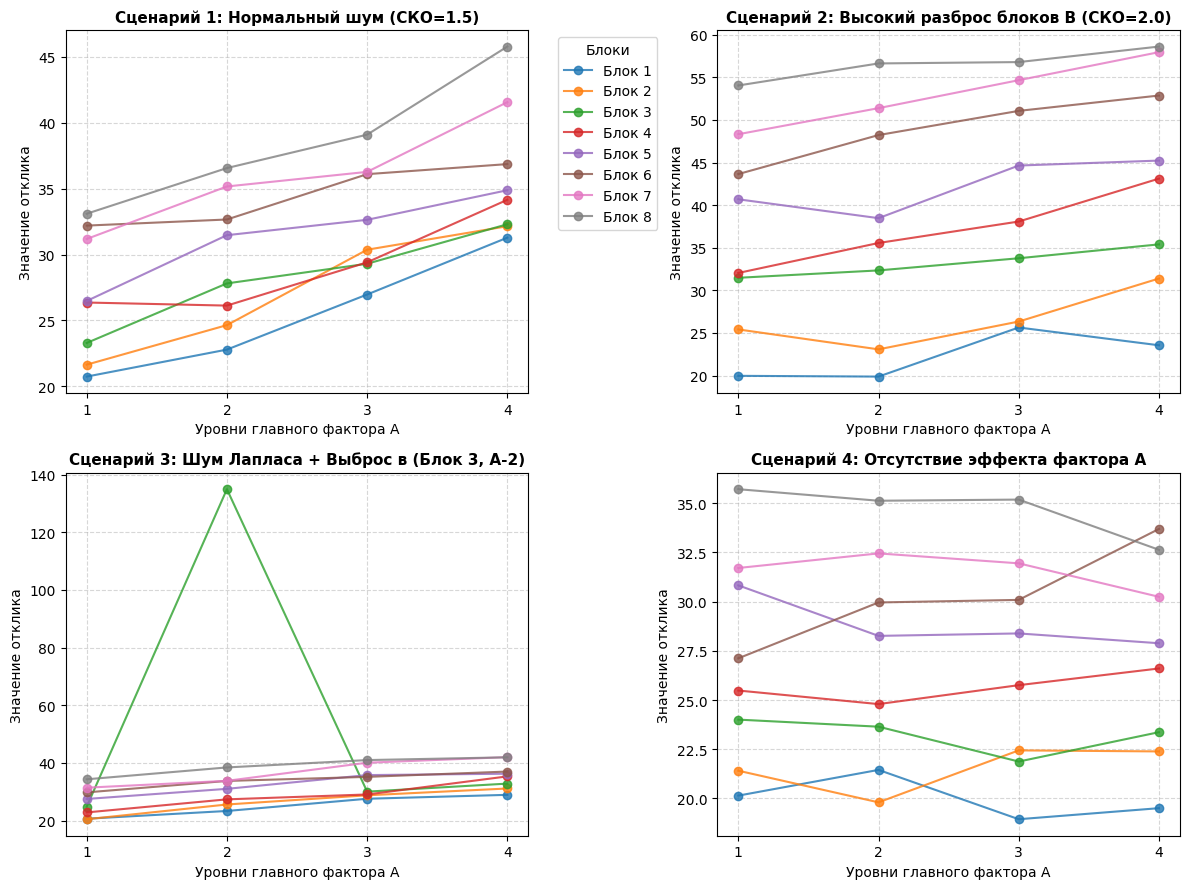

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
scen_matrices = [Y1, Y2, Y3, Y4]
titles = [
    'Сценарий 1: Нормальный шум (СКО=1.5)',
    'Сценарий 2: Высокий разброс блоков B (СКО=2.0)',
    'Сценарий 3: Шум Лапласа + Выброс в (Блок 3, А-2)',
    'Сценарий 4: Отсутствие эффекта фактора А'
]

for idx, (Y, title) in enumerate(zip(scen_matrices, titles)):
    ax = axes[idx]
    for block in range(n):
        ax.plot(range(1, k+1), Y[block, :], marker='o', alpha=0.8, label=f'Блок {block+1}' if idx==0 else "")
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Уровни главного фактора А')
    ax.set_ylabel('Значение отклика')
    ax.set_xticks(range(1, k+1))
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Блоки")
plt.tight_layout()
plt.show()

# Анализ результатов
### Сценарий 1: Эталонный случай (Нормальный шум)

* **Результаты:** Двухфакторный Фишер ($p = 0.0000$), Фридман ($p = 0.0000$), Пейдж ($L = 239.0, p = 0.0000$).
* **Объяснение:** В этом сценарии присутствует чистый, монотонно возрастающий эффект главного фактора $A$ ($0 \rightarrow +3 \rightarrow +6 \rightarrow +9$), а случайная ошибка распределена нормально без выбросов.
* **Фишер** легко находит эти различия, так как модель полностью соответствует его теоретическим предпосылкам.
* **Фридман** фиксирует стабильный сдвиг рангов от уровня к уровню.
* **Пейдж** выдает значение статистики $L = 239.0$, что почти равно абсолютному теоретическому максимуму ($240.0$). Это происходит потому, что реальное упорядочение уровней идеально совпало с ожидаемым направленным трендом.


* **Вывод:** В идеальных условиях (нормальное распределение, отсутствие выбросов, упорядоченный тренд) все критерии обладают высокой мощностью и безошибочно отвергают нулевую гипотезу $H_0$.

---

### Сценарий 2: Сильный шум блоков $B$ и слабый эффект $A$

* **Результаты:** Однофакторный Фишер ($p = 0.7142$) **vs** Двухфакторный Фишер ($p = 0.0000$).
* **Объяснение:** Этот сценарий — ключевой в лабораторной работе, так как он отвечает на вопрос: *«Когда двухфакторный анализ лучше однофакторного?»*.
* Здесь мешающий фактор блоков $B$ имеет огромный шаг (+5), растягивая значения отклика от 0 до +35. При этом главный фактор $A$ имеет скромный шаг (+2).
* **Однофакторный Фишер полностью «ослеп» ($p = 0.7142 > 0.05$)**. Он проигнорировал существование блоков, свалил весь этот огромный межблочный разброс в общую кучу со случайной ошибкой. В результате «шум» оказался настолько велик, что слабый сигнал от фактора $A$ в нем просто утонул.
* **Двухфакторный Фишер ($p = 0.0000$)** математически расщепил дисперсию, изолировал («вычел») влияние блоков $B$ из ошибки. Очищенная случайная ошибка стала маленькой, и критерий четко увидел закономерность фактора $A$.
* Непараметрические критерии (**Фридман** и **Пейдж**) также без проблем отвергли $H_0$ ($p < 0.05$). Поскольку они ранжируют данные *внутри* каждой строки (каждого блока отдельно), гигантский вертикальный разнос между самими строками на них вообще никак не повлиял.


* **Вывод:** Двухфакторный анализ кардинально лучше однофакторного, когда мешающий (блокирующий) фактор оказывает сильное и системное влияние на данные. Однофакторный анализ в таких условиях бесполезен.

---

### Сценарий 3: Нарушение нормальности и дикий выброс

* **Результаты:** Двухфакторный Фишер ($p = 0.3750$) **vs** Критерий Фридмана ($p = 0.0001$).
* **Объяснение:** Этот случай демонстрирует свойство **робастности** (устойчивости) критериев. По условию, в третьем блоке на втором уровне фактора $A$ значение отклика было искусственно увеличено в 5 раз.
* **Фишер сломался ($p = 0.3750 > 0.05$)** и совершил ошибку второго рода (не заметил реальный эффект фактора $A$). Параметрический ANOVA работает с квадратами отклонений. Один колоссальный выброс взвинтил остаточную сумму квадратов ($SS_{Error}$) до небес. Критерий посчитал, что в данных царит хаос, и потерял чувствительность к фактору $A$.
* **Фридман отработал блестяще ($p = 0.0001$)**. Ему безразличен масштаб выброса. При ранжировании внутри третьей строки аномально большое число просто получило свой максимальный ранг `4`. Выброс превратился в обычную четверку и потерял свою разрушительную силу, позволив критерию спокойно определить закономерность по остальным 7 блокам.


* **Вывод:** При наличии тяжелых хвостов распределения или единичных грубых ошибок (выбросов) параметрический критерий Фишера становится немощным. В таких ситуациях необходимо применять непараметрический критерий Фридмана.

---

### Сценарий 4: Отсутствие эффекта фактора $A$ (Контрольный)

* **Результаты:** Двухфакторный Фишер ($p = 0.9895$), Фридман ($p = 0.8614$).
* **Объяснение:** В этом сценарии эффекты уровней $A$ принудительно занулены (`[0, 0, 0, 0]`). На систему воздействуют только блоки $B$ и случайный нормальный шум.
* Оба критерия выдали высокие значения $p$-value, близкие к единице (существенно больше $\alpha = 0.05$).
* Это говорит о том, что критерии работают корректно: они не видят фантомных трендов и успешно принимают истинную нулевую гипотезу $H_0$. Вероятность ошибки первого рода (ложного срабатывания) находится в пределах нормы.


* **Вывод:** Критерии обладают хорошей избирательностью и не дают ложноположительных результатов при отсутствии реального воздействия фактора.

---

### Общее резюме для выводов лабораторной работы:

1. **Двухфакторный анализ необходим**, когда на объект исследования одновременно с главным фактором воздействует предсказуемый, но мешающий внешний фактор (например: разные приборы, разные дни эксперимента, сильный разброс исходного сырья). Он «очищает» данные от блочного шума.
2. **Критерий Фишера (параметрический)** — самый мощный инструмент, но только тогда, когда данные «чистые» и подчиняются нормальному закону.
3. **Критерий Фридмана (непараметрический)** — незаменим в реальных инженерных задачах, где возможны сбои оборудования, выбросы и аномалии, так как ранговая структура полностью защищает его от экстремальных искажений.
4. **Критерий Пейджа** — узкоспециализированный и максимально мощный инструмент для тех физических процессов, где отклик обязан строго монотонно возрастать или затухать (например, рост прочности бетона со временем, увеличение износа от пробега).